SYRIATEL CUSTOMER CHURN PREDICTION

1. Project Overview and Business Understanding
Project Overview:
This project addresses customer attrition(churn) at SyriaTel. By analyzing 3,333 customer records, we aim to build a predictive classification model that identifies patterns in customer usage and behavior that lead to churn.

Business Problem:
The cost of acquiring a new customer is significantly higher than retaining an existing one. SyriaTel needs a way to proactively identify customers likely to leave so that the retention team can intervene with loyalty programs or plan adjustments such as service improvements.

Stakeholders:

SyriaTel Retention Team: Primary users of the model to guide customer outreach.

Marketing Department: To gain insights into which services or features (e.g., international plans) influence customer dissatisfaction and churn.

Key Research Questions:

1.Which customer behaviors (e.g., international calling, support interactions) are the strongest indicators of churn?

2.Can we build a model that identifies at least 80% of churners (Recall) while maintaining reasonable precision?

3.What specific interventions can be recommended based on the model's findings?

2. Data Loading & Understanding
We begin by loading the dataset and performing an initial check of the structure.


In [3]:
#importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_curve, auc

# Load data
df = pd.read_csv('bigml_59c28831336c6604c800002a.csv')

# Data Understanding
print(f"Dataset Shape: {df.shape}")
print("\nColumn Info:")
df.info()
print("\nClass Distribution (Churn):")
print(df['churn'].value_counts(normalize=True))

Dataset Shape: (3333, 21)

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  

3. Data Cleaning
We handle non-numeric data, drop irrelevant identifiers, and prepare the target variable.

In [4]:
# 1. Drop identifiers that offer no predictive power
df.drop(columns=['phone number'], inplace=True)

# 2. Convert target variable to binary (0 and 1)
df['churn'] = df['churn'].astype(int)

# 3. Handle Categorical Encoding
# Area code is numerical but categorical in nature
df['area code'] = df['area code'].astype(str)

# One-hot encoding for State, Area Code, and International/VMail plans
df = pd.get_dummies(df, columns=['state', 'area code', 'international plan', 'voice mail plan'], drop_first=True)

# 4. Check for nulls (though SyriaTel is usually clean)
print(f"Missing values: {df.isnull().sum().sum()}")

Missing values: 0


4. Exploratory Data Analysis (EDA)
Visualizing the relationships between features and churn is crucial for the "Business Understanding".

1. Target Distribution: The Churn Imbalance

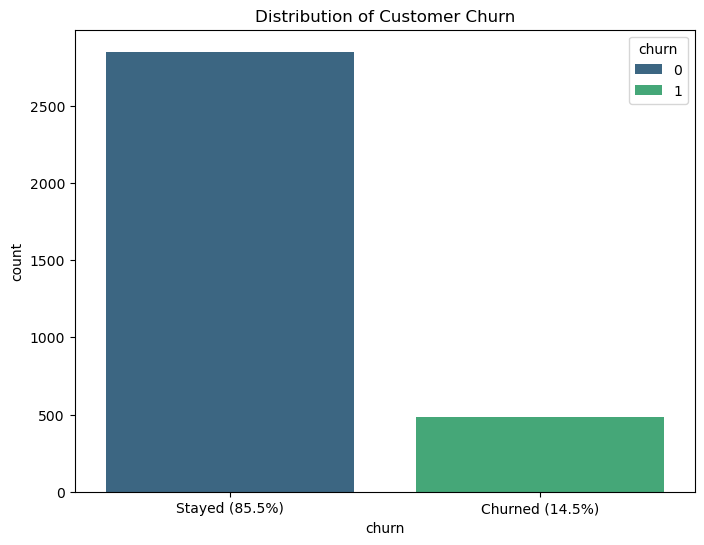

In [8]:
plt.figure(figsize=(8, 6))
sns.countplot(x='churn', data=df, palette='viridis', hue='churn')
plt.title('Distribution of Customer Churn')
plt.xticks([0, 1], ['Stayed (85.5%)', 'Churned (14.5%)'])
plt.show()

The Insight:
The dataset is significantly imbalanced, with only about 14.5% of customers actually leaving.

Business Implication: If we built a "dumb" model that simply guessed everyone would stay, it would be 85% accurate but useless for saving the business. This confirms we must prioritize Recall (finding the small group that leaves) over simple Accuracy.

2. Customer Service: The "Point of No Return"

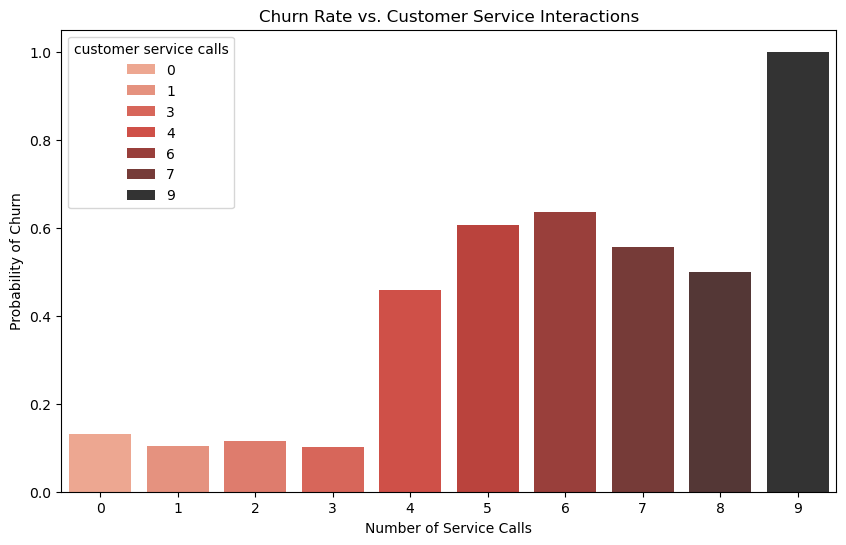

In [13]:
plt.figure(figsize=(10, 6))
sns.barplot(x='customer service calls', y='churn', data=df, errorbar=None, palette='Reds_d', hue='customer service calls')
plt.title('Churn Rate vs. Customer Service Interactions')
plt.xlabel('Number of Service Calls')
plt.ylabel('Probability of Churn')
plt.show()

The Insight:
There is a sharp increase in churn after the 3rd customer service call, indicating a critical failure point in issue resolution.

Business Implication: A customer calling for the 4th time has a nearly 50% chance of leaving. This indicates that our current support process fails to resolve deep-seated issues within the first three attempts. We should flag any customer on their 3rd call for immediate escalation.

3. Day Minutes: The "Power User" Paradox

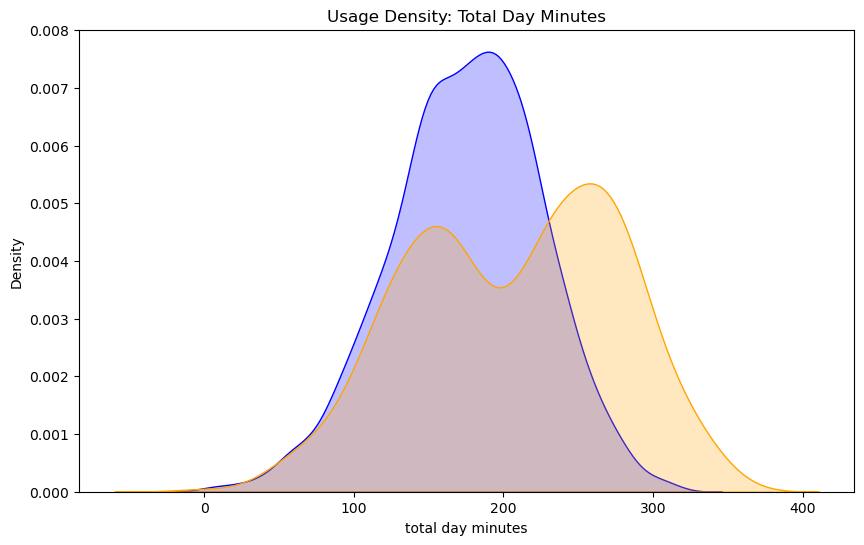

In [15]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['churn'] == 0]['total day minutes'], label='Stayed', fill=True, color='blue')
sns.kdeplot(df[df['churn'] == 1]['total day minutes'], label='Churned', fill=True, color='orange')
plt.title('Usage Density: Total Day Minutes')
plt.show()

The Insight:
Churned customers (orange) have a much higher concentration in the high-usage zone (250+ minutes per day).

Business Implication: Our most loyal-looking users (the heavy callers) are actually our highest-risk users. They likely have high bills and are highly sensitive to price changes. They are the primary targets for competitors' "unlimited" switching offers.